In [6]:
import numpy as np
import polars as pl
import lake_explorer as le
import polar_lake_explorer as ple
import consolidate_lake as cl
import matplotlib.pyplot as plt

In [7]:
# Verificar/crear el Parquet consolidado (smart cache)
# Solo reconstruye si cambió el número de campañas/archivos CSV
DATA_LAKE_PATH = "/mnt/c/Users/Asus/cern_db/dihiggs_lake"

parquet_path = cl.get_parquet_path()
print(f"Parquet: {parquet_path}")

[consolidate] Parquet up-to-date ✔  (75,093,639 rows)
              /home/fabi/cern_db/dihiggs_consolidated/dihiggs_lake.parquet
Parquet: /home/fabi/cern_db/dihiggs_consolidated/dihiggs_lake.parquet


In [8]:
# =========================
# Configuración
# =========================
BR_RANGE = (1e-1, 1.0)
TDW_RANGE = (0.0, 1e-11)
BINS = 60
MAX_VARS_TO_PLOT = 8


# =========================
# Helpers de integración
# =========================
def _resolve_col(schema_names, aliases):
    lower_map = {c.lower(): c for c in schema_names}
    for a in aliases:
        if a.lower() in lower_map:
            return lower_map[a.lower()]
    for c in schema_names:
        cl_ = c.lower()
        if any(tok in cl_ for tok in aliases):
            return c
    return None


def _numeric_columns(lf: pl.LazyFrame):
    s = lf.collect_schema()
    numeric_dtypes = {
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64, pl.Decimal
    }
    cols = []
    for c in s.names():
        dt = s[c]
        if dt in numeric_dtypes:
            cols.append(c)
    return cols


def _hist_counts_lazy(lf: pl.LazyFrame, col: str, bins: int):
    mm = lf.select(
        pl.col(col).min().alias("min_v"),
        pl.col(col).max().alias("max_v")
    ).collect()

    vmin = mm["min_v"][0]
    vmax = mm["max_v"][0]

    if vmin is None or vmax is None:
        return np.array([]), np.array([])

    if vmax == vmin:
        edges = np.array([vmin, vmax + 1e-12])
        counts = np.array([lf.select(pl.len()).collect().item()], dtype=float)
        return edges, counts

    bin_expr = (
        (((pl.col(col) - vmin) / (vmax - vmin)) * bins)
        .floor()
        .cast(pl.Int32)
        .clip(0, bins - 1)
        .alias("_bin")
    )

    h = (
        lf.select(bin_expr)
        .group_by("_bin")
        .len()
        .sort("_bin")
        .collect()
    )

    counts = np.zeros(bins, dtype=float)
    if h.height > 0:
        idx = h["_bin"].to_numpy()
        cnt = h["len"].to_numpy()
        counts[idx] = cnt

    edges = np.linspace(vmin, vmax, bins + 1)
    return edges, counts


def plot_distribution_compare(df_total_lazy: pl.LazyFrame, df_subset: pl.DataFrame, variables, bins=60):
    subset_lazy = df_subset.lazy()

    n = len(variables)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(variables):
        ax = axes[i]

        edges_t, cnt_t = _hist_counts_lazy(
            df_total_lazy.filter(pl.col(col).is_not_null()),
            col,
            bins=bins
        )
        edges_s, cnt_s = _hist_counts_lazy(
            subset_lazy.filter(pl.col(col).is_not_null()),
            col,
            bins=bins
        )

        if len(cnt_t) == 0 or len(cnt_s) == 0:
            ax.set_title(f"{col} (sin datos)")
            ax.axis("off")
            continue

        edges = edges_t
        if len(edges_t) != len(edges_s) or not np.allclose(edges_t, edges_s):
            vmin, vmax = edges[0], edges[-1]
            b = len(edges) - 1
            bin_expr = (
                (((pl.col(col) - vmin) / (vmax - vmin)) * b)
                .floor()
                .cast(pl.Int32)
                .clip(0, b - 1)
                .alias("_bin")
            )
            hs = (
                subset_lazy.filter(pl.col(col).is_not_null())
                .select(bin_expr)
                .group_by("_bin")
                .len()
                .sort("_bin")
                .collect()
            )
            cnt_s = np.zeros(b, dtype=float)
            if hs.height > 0:
                cnt_s[hs["_bin"].to_numpy()] = hs["len"].to_numpy()

        if cnt_t.sum() > 0:
            cnt_t = cnt_t / cnt_t.sum()
        if cnt_s.sum() > 0:
            cnt_s = cnt_s / cnt_s.sum()

        centers = 0.5 * (edges[:-1] + edges[1:])
        width = (edges[1] - edges[0]) * 0.45

        ax.bar(centers - width / 2, cnt_t, width=width, alpha=0.55, label="total", color="#1f77b4")
        ax.bar(centers + width / 2, cnt_s, width=width, alpha=0.55, label="subset", color="#ff7f0e")
        ax.set_title(col)
        ax.set_ylabel("densidad")
        ax.grid(alpha=0.2)
        ax.legend()

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()




In [9]:
# =========================
# Flujo principal
# =========================
# Lazy-scan desde Parquet consolidado (ext4 nativo, sin SIGBUS)
# ple.scan_lake() internamente usa consolidate_lake.ensure_parquet()
df = ple.scan_lake(DATA_LAKE_PATH)

schema_names = df.collect_schema().names()
print(f"Columnas detectadas: {schema_names}")

# Resolver columnas de corte
br_col = _resolve_col(schema_names, ["br", "branching_ratio", "branching ratio", "br_gaga"])
tdw_col = _resolve_col(schema_names, ["total_decay_width", "total decay width", "decay_width", "width", "tdw", "total_width"])

if br_col is None or tdw_col is None:
    raise ValueError(
        f"No se pudieron resolver columnas de BR/Total Decay Width. "
        f"Columnas disponibles: {schema_names}"
    )

print(f"BR column → {br_col}")
print(f"TDW column → {tdw_col}")

# Subset con cortes (streaming=True caps memory usage)
df_subset = (
    df.filter(
        pl.col(br_col).is_between(BR_RANGE[0], BR_RANGE[1], closed="both")
        & pl.col(tdw_col).is_between(TDW_RANGE[0], TDW_RANGE[1], closed="both")
    )
    .collect()
)

print(f"\nTotal (lazy): {df}")
print(f"Filas en subset: {df_subset.height:,}")

[consolidate] Parquet up-to-date ✔  (75,093,639 rows)
              /home/fabi/cern_db/dihiggs_consolidated/dihiggs_lake.parquet
Columnas detectadas: ['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12', 'sin_ba', 'tan_beta', 'positivity_ok', 'unitarity_ok', 'perturbativity_ok', 'width_bb', 'width_tautau', 'width_WW', 'width_ZZ', 'width_gaga', 'width_Zga', 'width_gg', 'width_hh', 'total_width', 'br_gaga', 'lam1', 'computed_lam1', 'lam2', 'computed_lam2', 'lam3', 'lam4', 'lam5']
BR column → br_gaga
TDW column → total_width

Total (lazy): naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

Parquet SCAN [/home/fabi/cern_db/dihiggs_consolidated/dihiggs_lake.parquet]
PROJECT */29 COLUMNS
ESTIMATED ROWS: 75093639
Filas en subset: 2,353,200


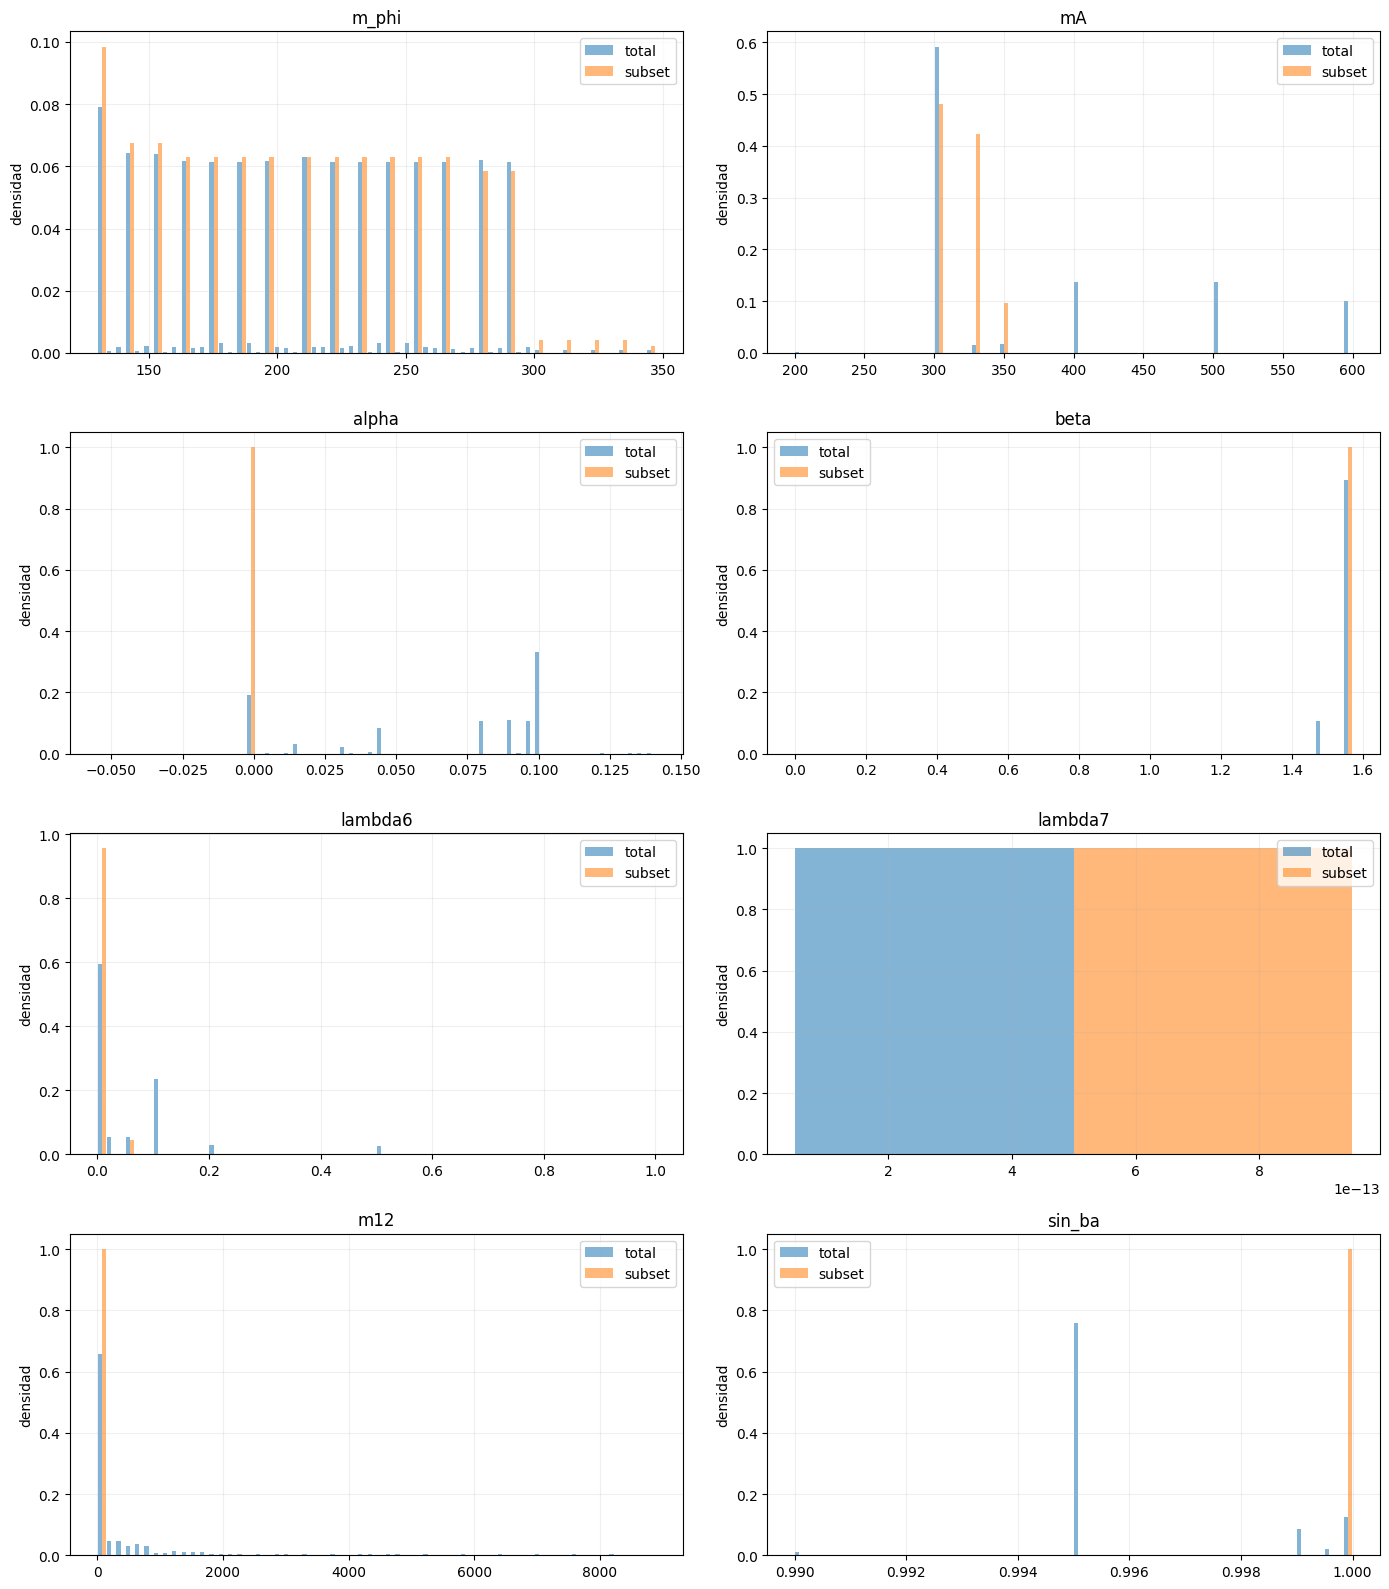

In [10]:

# Variables numéricas para comparar (excluye columnas de corte)
num_cols = [c for c in _numeric_columns(df) if c not in {br_col, tdw_col}]
variables_to_plot = num_cols[:MAX_VARS_TO_PLOT]

if len(variables_to_plot) == 0:
    raise ValueError("No hay variables numéricas disponibles para graficar.")

plot_distribution_compare(df, df_subset, variables_to_plot, bins=BINS)